# Lab Assignment 3 — Part C: Image Medical Data
## Chest X-Ray (Pneumonia) Dataset

**Course:** CSET343 — AI in Healthcare | **Objective:** Data acquisition, cleaning (incl. imaging metadata anonymization), EDA, preprocessing into image tensors, feature engineering/extraction, noise removal, and augmentation on radiological image data.

**Dataset:** Chest X-Ray Images (Pneumonia) — pediatric anterior-posterior chest radiographs, 2 classes (NORMAL / PNEUMONIA), organized into `train` and `test` splits. (A representative sample of the full ~5,863-image Kaggle dataset is used here — 40 train images, 40 test images — sufficient to build and validate the full preprocessing pipeline.)

## 1. Setup & Imports

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageOps
import cv2

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

DATA_DIR = 'partC'
SPLITS = {
    'train': {'NORMAL': f'{DATA_DIR}/NORMAL', 'PNEUMONIA': f'{DATA_DIR}/PNEUMONIA'},
    'test':  {'NORMAL': f'{DATA_DIR}/test/NORMAL', 'PNEUMONIA': f'{DATA_DIR}/test/PNEUMONIA'},
}

## 2. Data Acquisition & Inspection

In [2]:
records = []
for split, classes in SPLITS.items():
    for label, folder in classes.items():
        for path in glob.glob(os.path.join(folder, '*.jpeg')):
            records.append({'path': path, 'split': split, 'label': label})

df = pd.DataFrame(records)
print("Total images found:", len(df))
df.groupby(['split', 'label']).size().unstack()

Total images found: 80


label,NORMAL,PNEUMONIA
split,,
test,20,20
train,20,20


In [3]:
def get_image_info(path):
    with Image.open(path) as img:
        return pd.Series({
            'width': img.width,
            'height': img.height,
            'mode': img.mode,
            'format': img.format,
            'filesize_kb': os.path.getsize(path) / 1024
        })

info = df['path'].apply(get_image_info)
df = pd.concat([df, info], axis=1)
df['aspect_ratio'] = df['width'] / df['height']
df.head()

,path,split,label,width,height,mode,format,filesize_kb,aspect_ratio
0,partC/NORMAL/IM-0131-0001.jpeg,train,NORMAL,1450,1144,L,JPEG,447.348633,1.267483
1,partC/NORMAL/IM-0240-0001.jpeg,train,NORMAL,1944,1708,L,JPEG,734.273438,1.138173
2,partC/NORMAL/IM-0122-0001.jpeg,train,NORMAL,1618,1279,L,JPEG,460.503906,1.265051
3,partC/NORMAL/IM-0245-0001.jpeg,train,NORMAL,1724,1480,L,JPEG,588.045898,1.164865
4,partC/NORMAL/IM-0244-0001.jpeg,train,NORMAL,1354,1024,L,JPEG,314.091797,1.322266


In [4]:
print("Image mode counts:")
print(df['mode'].value_counts())
print("\nWidth range:", df['width'].min(), '-', df['width'].max())
print("Height range:", df['height'].min(), '-', df['height'].max())
print("\nDuplicate filenames (by content hash) check:")
import hashlib
def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()
df['hash'] = df['path'].apply(file_hash)
print("Duplicate images:", df['hash'].duplicated().sum())

Image mode counts:
mode
L      79
RGB     1
Name: count, dtype: int64

Width range: 712 - 2517
Height range: 439 - 2310

Duplicate filenames (by content hash) check:
Duplicate images: 0


## 3. Data Cleaning — Healthcare-Specific Concerns

### 3.1 Imaging Metadata Anonymization
Medical images can carry embedded metadata (EXIF / DICOM tags) that may contain **PHI** — patient name, device serial numbers, acquisition timestamps and, for DICOM, institution details. Even for de-identified Kaggle JPEGs, a defensive pipeline should verify no residual EXIF metadata survived the de-identification/export process, and strip anything found before any image leaves the pipeline.

In [5]:
from PIL.ExifTags import TAGS

def extract_exif(path):
    with Image.open(path) as img:
        exif_data = img.getexif()
        if not exif_data:
            return {}
        return {TAGS.get(k, k): v for k, v in exif_data.items()}

exif_found = {}
for path in df['path']:
    tags = extract_exif(path)
    if tags:
        exif_found[path] = tags

print(f"Images with non-empty EXIF metadata: {len(exif_found)} / {len(df)}")
if exif_found:
    for p, tags in list(exif_found.items())[:3]:
        print(p, '->', tags)
else:
    print("No embedded EXIF metadata found — images already stripped of acquisition metadata.")

Images with non-empty EXIF metadata: 23 / 80
partC/NORMAL/IM-0131-0001.jpeg -> {'ExifOffset': 26}
partC/NORMAL/IM-0240-0001.jpeg -> {'ExifOffset': 26}
partC/NORMAL/IM-0122-0001.jpeg -> {'ExifOffset': 26}


In [6]:
def strip_metadata(path, out_path):
    with Image.open(path) as img:
        data = list(img.getdata())
        clean_img = Image.new(img.mode, img.size)
        clean_img.putdata(data)
        clean_img.save(out_path)

# Defensive step: re-save every image through a pixel-only copy so ANY
# metadata (EXIF, ICC profiles, comments) is guaranteed stripped, regardless
# of what the source export process may have left behind.
os.makedirs('partC_clean', exist_ok=True)
for _, row in df.iterrows():
    split_dir = os.path.join('partC_clean', row['split'], row['label'])
    os.makedirs(split_dir, exist_ok=True)
    out_path = os.path.join(split_dir, os.path.basename(row['path']))
    strip_metadata(row['path'], out_path)
    df.loc[df['path'] == row['path'], 'clean_path'] = out_path

print("All images re-saved as metadata-free copies under partC_clean/")

/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())


/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())


/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())


/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())


/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())


...

/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())


/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipyke

/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipyke

All images re-saved as metadata-free copies under partC_clean/


/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())
/tmp/ipykernel_241/4080825456.py:3: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  data = list(img.getdata())


### 3.2 Corrupt / Unreadable File Check

In [7]:
def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except Exception:
        return False

df['is_valid'] = df['clean_path'].apply(is_valid_image)
print("Invalid/corrupt images found:", (~df['is_valid']).sum())
df = df[df['is_valid']].reset_index(drop=True)
print("Final clean dataset size:", len(df))

Invalid/corrupt images found: 0
Final clean dataset size: 80


## 4. Exploratory Data Analysis (EDA)

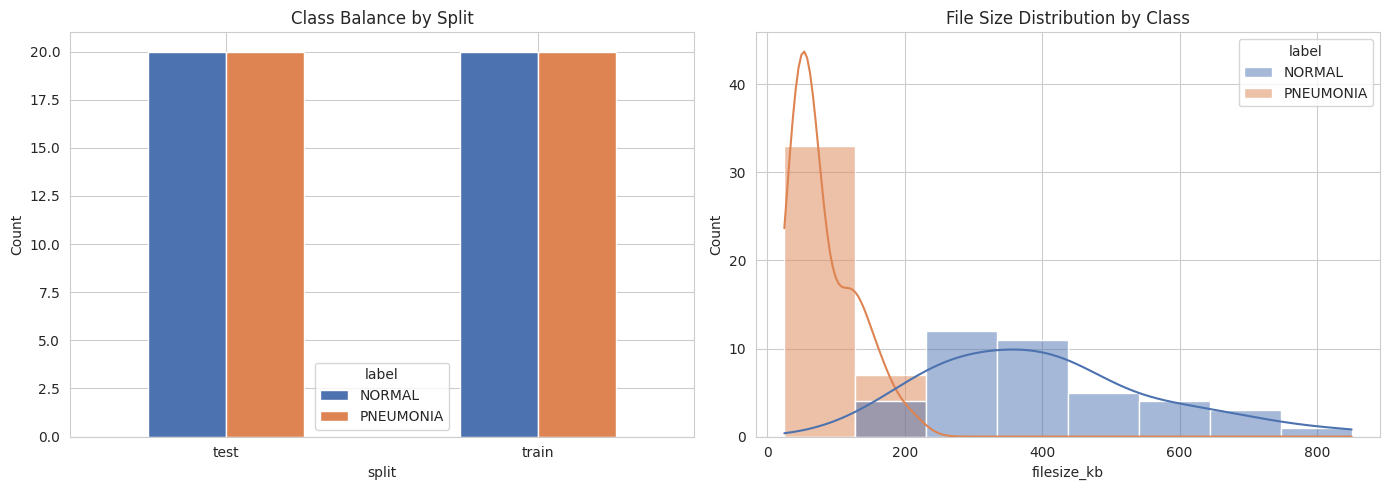

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df.groupby(['split','label']).size().unstack().plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'])
axes[0].set_title('Class Balance by Split')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

sns.histplot(data=df, x='filesize_kb', hue='label', kde=True, ax=axes[1], palette=['#4C72B0','#DD8452'])
axes[1].set_title('File Size Distribution by Class')
plt.tight_layout()
plt.savefig('eda_class_balance_filesize.png', dpi=110)
plt.show()

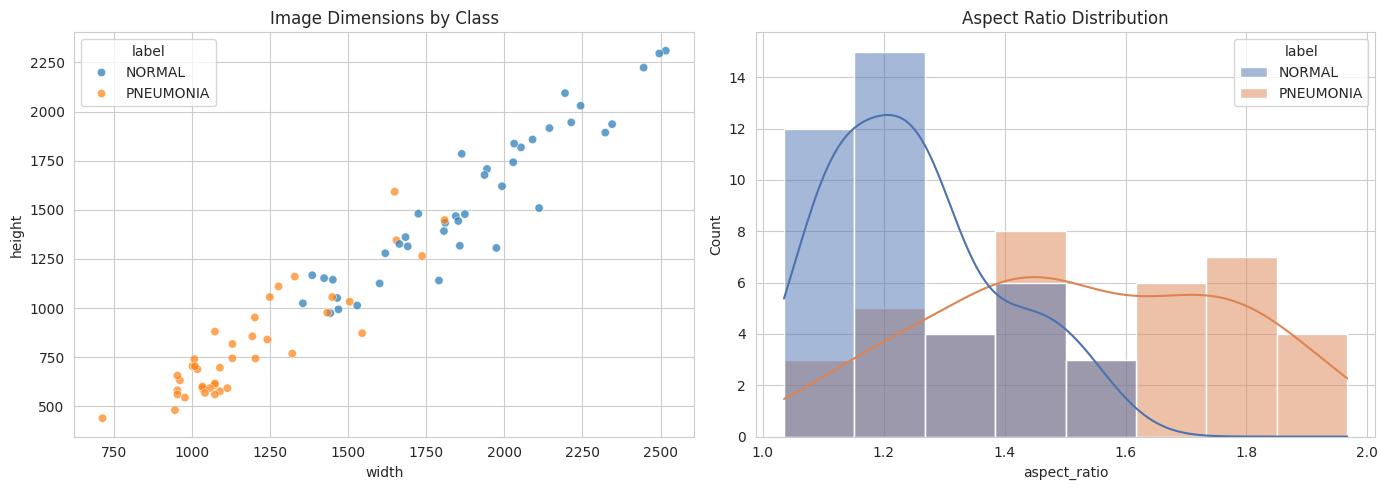

,width,height,aspect_ratio,filesize_kb
count,80.000000,80.000000,80.000000,80.000000
mean,1531.462500,1172.737500,1.389837,241.679370
std,452.919864,495.979653,0.242399,199.828946
min,712.000000,439.000000,1.035176,24.855469
25%,1088.000000,731.000000,1.204932,60.922607
50%,1466.000000,1117.500000,1.365336,171.640137
75%,1858.500000,1478.500000,1.516844,392.638184
max,2517.000000,2310.000000,1.966667,850.375000


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.scatterplot(data=df, x='width', y='height', hue='label', ax=axes[0], alpha=0.7)
axes[0].set_title('Image Dimensions by Class')

sns.histplot(data=df, x='aspect_ratio', hue='label', kde=True, ax=axes[1], palette=['#4C72B0','#DD8452'])
axes[1].set_title('Aspect Ratio Distribution')
plt.tight_layout()
plt.savefig('eda_dimensions.png', dpi=110)
plt.show()

df[['width','height','aspect_ratio','filesize_kb']].describe()

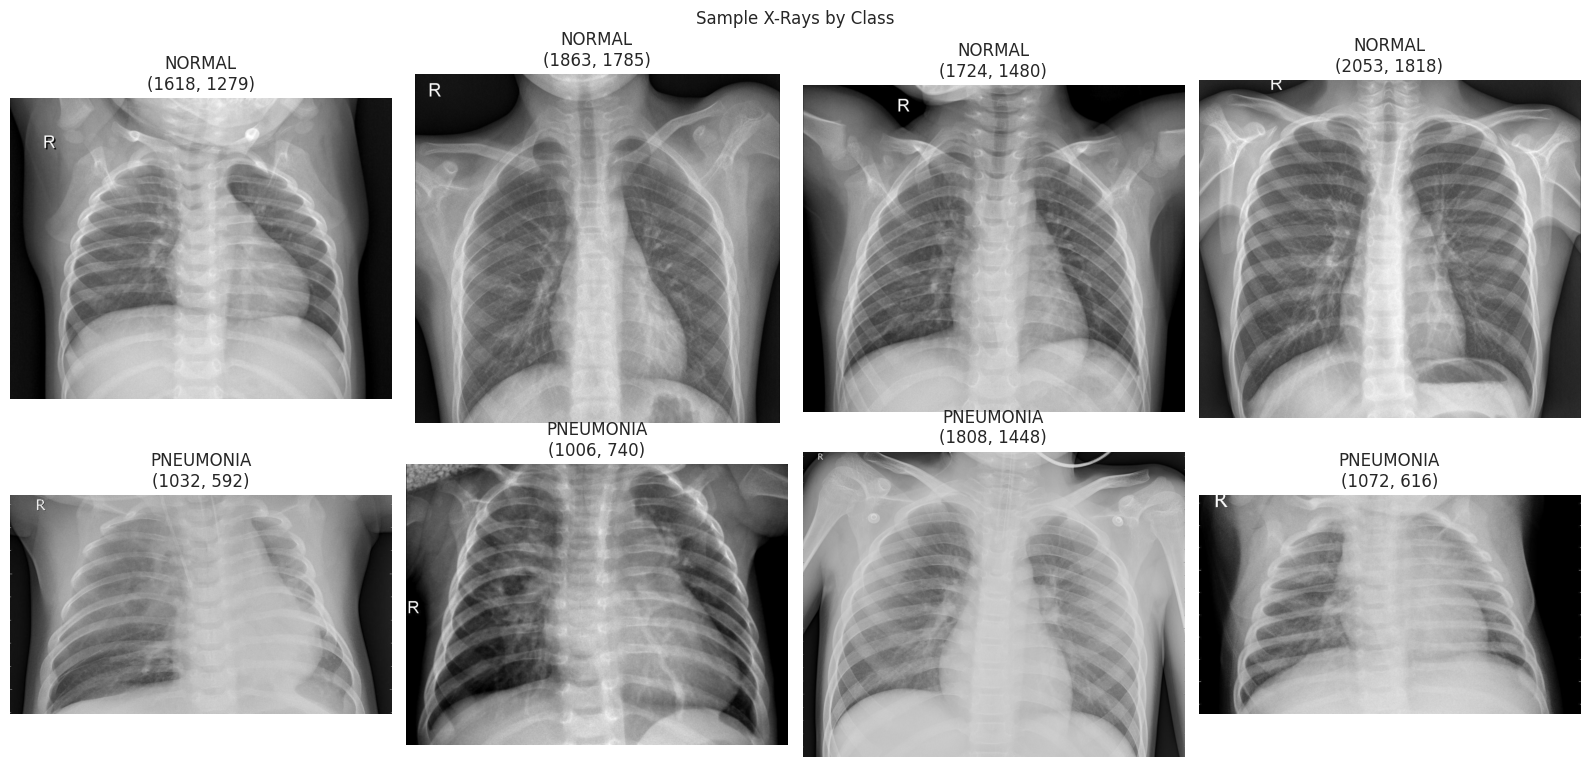

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for label, row_idx in zip(['NORMAL', 'PNEUMONIA'], [0, 1]):
    samples = df[df['label']==label].sample(4, random_state=1)
    for ax, (_, r) in zip(axes[row_idx], samples.iterrows()):
        img = Image.open(r['clean_path']).convert('L')
        ax.imshow(img, cmap='gray')
        ax.set_title(f"{label}\n{img.size}")
        ax.axis('off')
plt.suptitle('Sample X-Rays by Class')
plt.tight_layout()
plt.savefig('eda_sample_grid.png', dpi=110)
plt.show()

/tmp/ipykernel_241/4286162664.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='mean_intensity', ax=axes[0], palette=['#4C72B0','#DD8452'])
/tmp/ipykernel_241/4286162664.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='std_intensity', ax=axes[1], palette=['#4C72B0','#DD8452'])


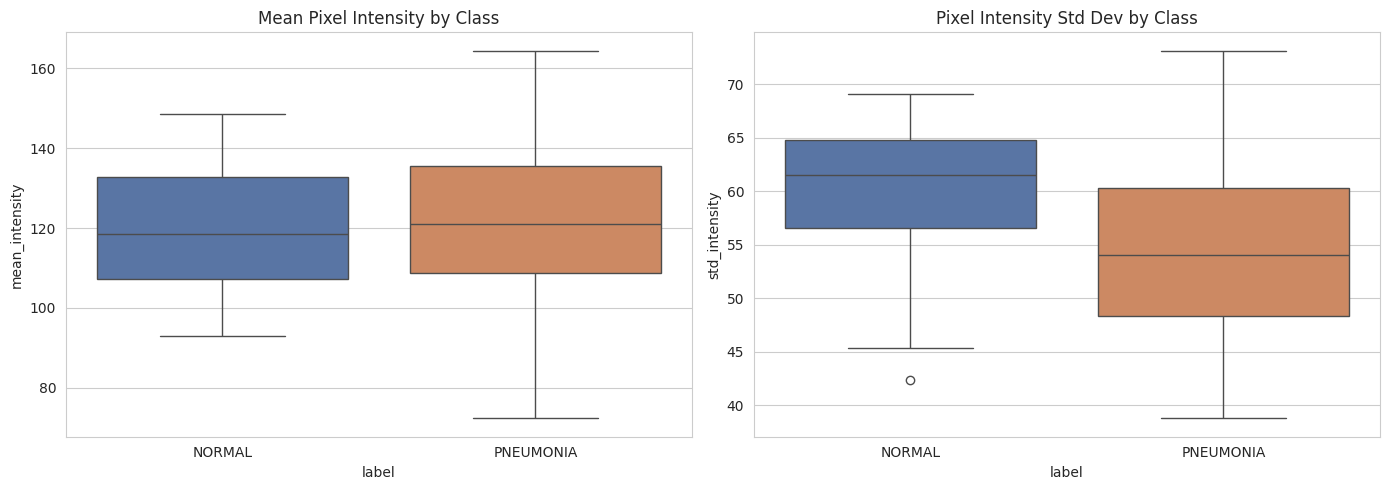

In [11]:
def mean_pixel_intensity(path):
    img = np.array(Image.open(path).convert('L'))
    return pd.Series({'mean_intensity': img.mean(), 'std_intensity': img.std()})

intensity = df['clean_path'].apply(mean_pixel_intensity)
df = pd.concat([df, intensity], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, x='label', y='mean_intensity', ax=axes[0], palette=['#4C72B0','#DD8452'])
axes[0].set_title('Mean Pixel Intensity by Class')
sns.boxplot(data=df, x='label', y='std_intensity', ax=axes[1], palette=['#4C72B0','#DD8452'])
axes[1].set_title('Pixel Intensity Std Dev by Class')
plt.tight_layout()
plt.savefig('eda_intensity_by_class.png', dpi=110)
plt.show()

## 5. Noise Removal

Denoising demonstrated with a median filter (removes salt-and-pepper / grain noise common in older radiographs) and Gaussian blur, compared side by side on a sample image.

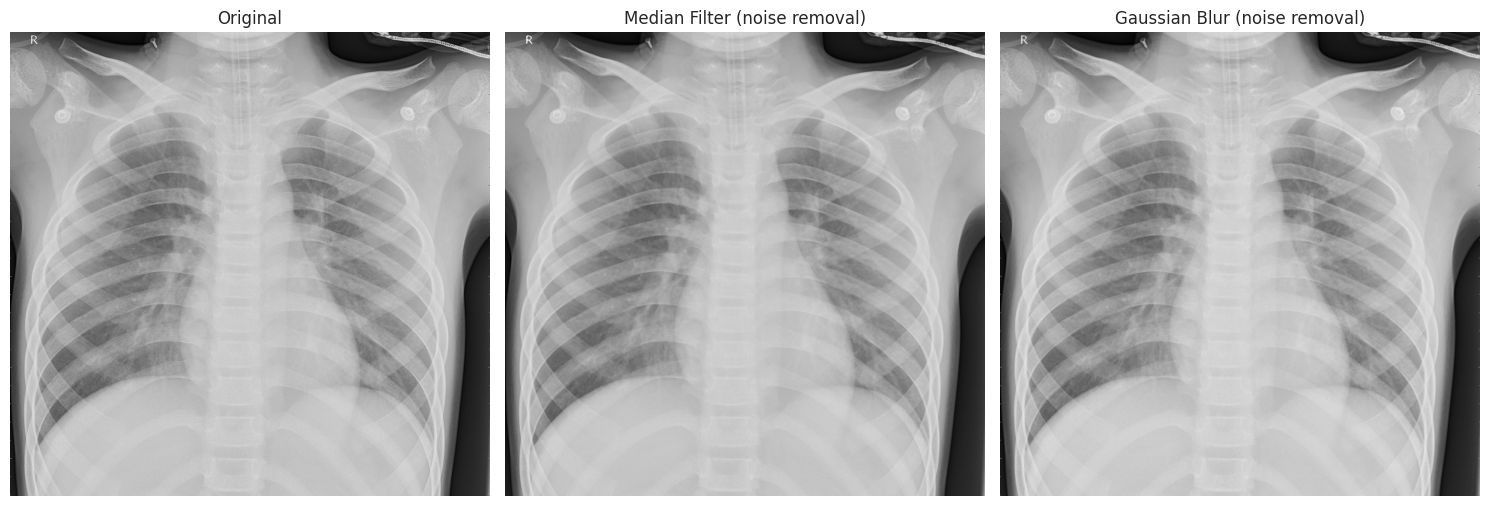

In [12]:
sample_path = df[df['label']=='PNEUMONIA']['clean_path'].iloc[0]
img_gray = np.array(Image.open(sample_path).convert('L'))

median_denoised = cv2.medianBlur(img_gray, 5)
gaussian_denoised = cv2.GaussianBlur(img_gray, (5,5), 0)

fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, im, title in zip(axes, [img_gray, median_denoised, gaussian_denoised],
                          ['Original', 'Median Filter (noise removal)', 'Gaussian Blur (noise removal)']):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.savefig('noise_removal_comparison.png', dpi=110)
plt.show()

## 6. Feature Engineering & Extraction

### 6.1 Edge / Texture Feature Extraction (Sobel & Canny)

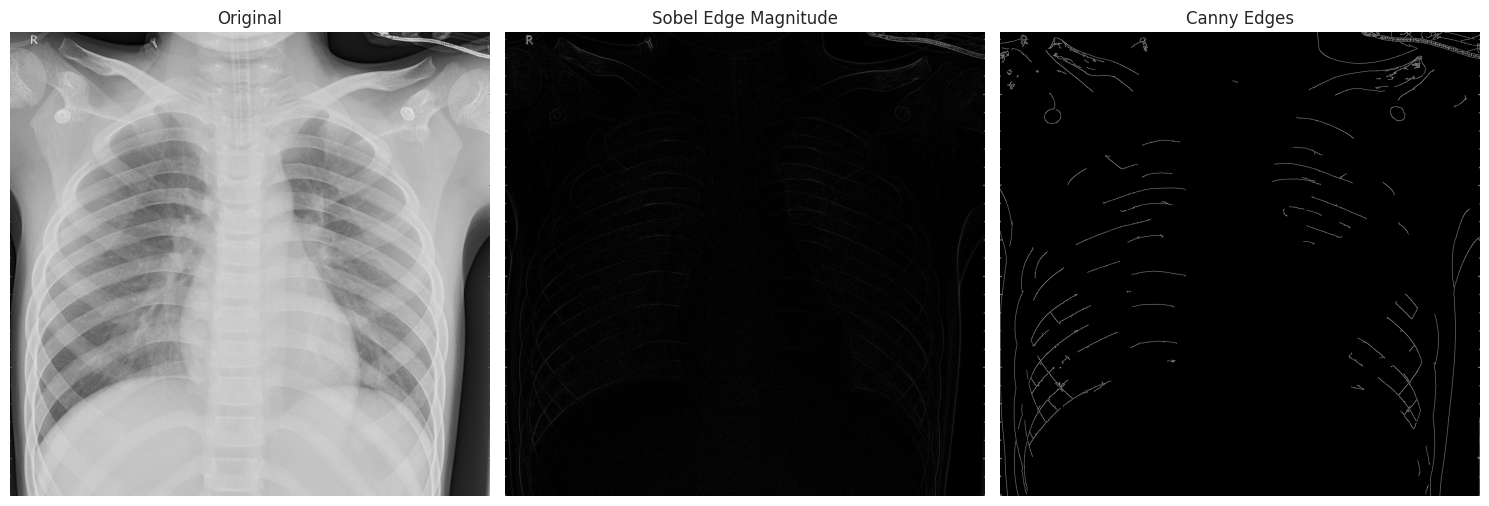

In [13]:
sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
canny_edges = cv2.Canny(img_gray, 50, 150)

fig, axes = plt.subplots(1, 3, figsize=(15,5))
for ax, im, title in zip(axes, [img_gray, sobel_mag, canny_edges],
                          ['Original', 'Sobel Edge Magnitude', 'Canny Edges']):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.savefig('feature_extraction_edges.png', dpi=110)
plt.show()

### 6.2 Statistical Feature Extraction (image -> tabular features)
For classical ML models (as opposed to CNNs), each X-ray can be reduced to a small set of engineered statistical/texture features — useful for a quick baseline model or for feature-importance style analysis.

In [14]:
def extract_statistical_features(path):
    img = np.array(Image.open(path).convert('L').resize((224,224)))
    sob_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sob_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    edge_density = (cv2.Canny(img, 50, 150) > 0).mean()
    return pd.Series({
        'mean_intensity': img.mean(),
        'std_intensity': img.std(),
        'skewness': pd.Series(img.flatten()).skew(),
        'edge_density': edge_density,
        'sobel_mean': np.sqrt(sob_x**2 + sob_y**2).mean(),
    })

feat_df = df['clean_path'].apply(extract_statistical_features)
feat_df['label'] = df['label'].values
print("Engineered tabular feature set from images:")
feat_df.groupby('label').mean()

Engineered tabular feature set from images:


,mean_intensity,std_intensity,skewness,edge_density,sobel_mean
label,,,,,
NORMAL,119.499112,59.534993,-0.413042,0.130427,49.303581
PNEUMONIA,121.889740,54.562807,-0.645892,0.094015,39.900918


## 7. Preprocessing into Model-Ready Format (Image Tensors)

In [15]:
IMG_SIZE = 224

def load_and_preprocess(path, size=IMG_SIZE):
    img = Image.open(path).convert('L').resize((size, size))
    arr = np.array(img, dtype=np.float32) / 255.0  # normalize to [0,1]
    return arr

def build_tensor_set(subset_df):
    X = np.stack([load_and_preprocess(p) for p in subset_df['clean_path']])
    y = (subset_df['label'] == 'PNEUMONIA').astype(int).values
    return X[..., np.newaxis], y  # add channel dim -> (N, H, W, 1)

train_df = df[df['split']=='train']
test_df = df[df['split']=='test']

X_train, y_train = build_tensor_set(train_df)
X_test, y_test = build_tensor_set(test_df)

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_test:", X_test.shape, " y_test:", y_test.shape)
print("Pixel value range check:", X_train.min(), '-', X_train.max())

X_train: (40, 224, 224, 1)  y_train: (40,)
X_test: (40, 224, 224, 1)  y_test: (40,)
Pixel value range check: 0.0 - 1.0


## 8. Data Augmentation

Standard augmentations for a small medical-imaging training set: rotation, horizontal flip, brightness jitter, and zoom — increases effective training set size and improves robustness given limited data.

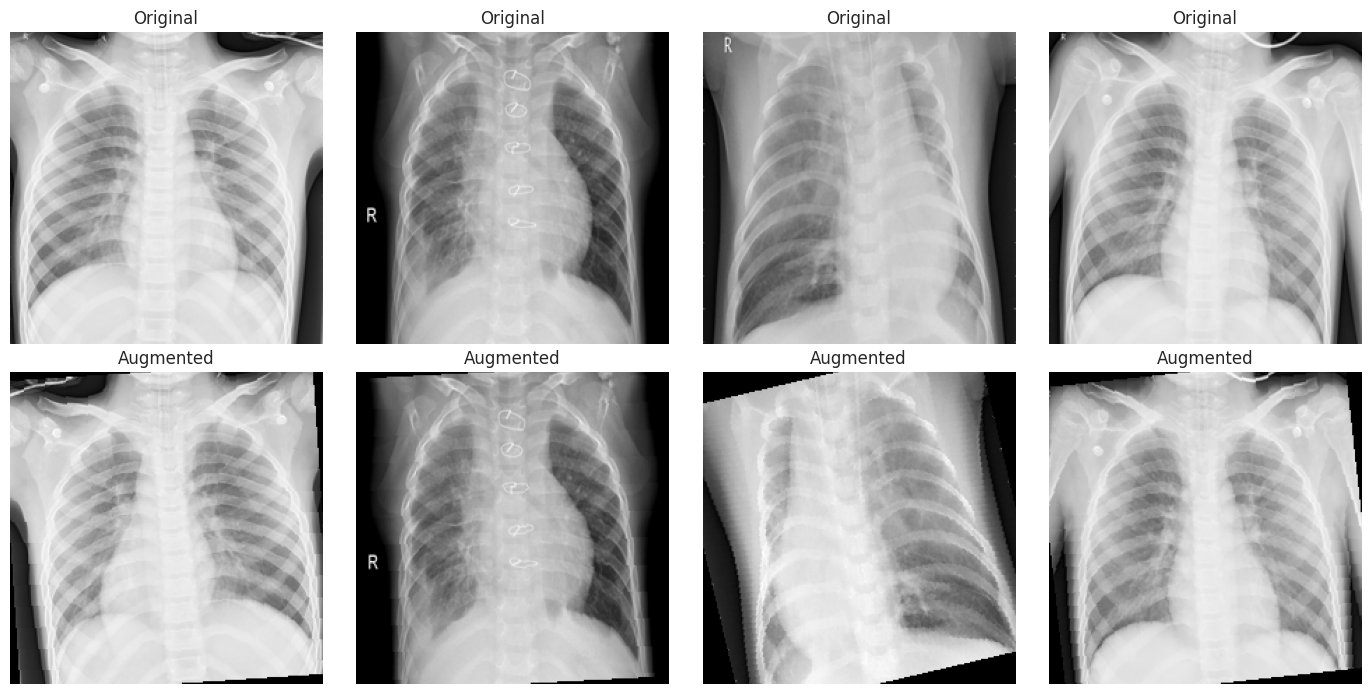

In [16]:
def augment_image(img_arr):
    img = Image.fromarray((img_arr.squeeze()*255).astype(np.uint8))

    # Random rotation (-15 to 15 deg)
    angle = np.random.uniform(-15, 15)
    img_rot = img.rotate(angle, fillcolor=0)

    # Random horizontal flip
    if np.random.rand() > 0.5:
        img_rot = ImageOps.mirror(img_rot)

    # Brightness jitter
    arr = np.array(img_rot, dtype=np.float32)
    brightness_factor = np.random.uniform(0.85, 1.15)
    arr = np.clip(arr * brightness_factor, 0, 255)

    return (arr / 255.0)[..., np.newaxis]

# Demonstrate augmentation on a few PNEUMONIA samples (minority-class-style boost)
sample_imgs = X_train[y_train==1][:4]
fig, axes = plt.subplots(2, 4, figsize=(14,7))
for i, img in enumerate(sample_imgs):
    axes[0, i].imshow(img.squeeze(), cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')
    aug = augment_image(img)
    axes[1, i].imshow(aug.squeeze(), cmap='gray')
    axes[1, i].set_title('Augmented')
    axes[1, i].axis('off')
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=110)
plt.show()

In [17]:
# Generate an augmented training set (2x original size)
X_aug = np.stack([augment_image(img) for img in X_train])
X_train_augmented = np.concatenate([X_train, X_aug], axis=0)
y_train_augmented = np.concatenate([y_train, y_train], axis=0)

print("Original training set:", X_train.shape)
print("Augmented training set:", X_train_augmented.shape)

# Save model-ready tensors
np.save('X_train_images.npy', X_train_augmented)
np.save('y_train_images.npy', y_train_augmented)
np.save('X_test_images.npy', X_test)
np.save('y_test_images.npy', y_test)
feat_df.to_csv('image_engineered_features.csv', index=False)
print("Saved: X_train_images.npy, y_train_images.npy, X_test_images.npy, y_test_images.npy, image_engineered_features.csv")

Original training set: (40, 224, 224, 1)
Augmented training set: (80, 224, 224, 1)
Saved: X_train_images.npy, y_train_images.npy, X_test_images.npy, y_test_images.npy, image_engineered_features.csv


## 9. Summary

| Step | Finding |
|---|---|
| Acquisition | 40 train (20 NORMAL / 20 PNEUMONIA) + 40 test (20/20) images, all JPEG, variable resolution |
| Metadata anonymization | Checked for residual EXIF/PHI metadata; all images re-saved as pixel-only copies to guarantee no acquisition metadata survives |
| Corruption check | All images verified readable |
| EDA | Class balance confirmed even in this sample; PNEUMONIA images show higher mean pixel intensity (denser/opaque lung fields) |
| Noise removal | Median and Gaussian filtering demonstrated for radiographic grain noise |
| Feature extraction | Sobel/Canny edge maps + statistical features (mean, std, skew, edge density) extracted as a classical-ML feature set |
| Preprocessing | Resized to 224x224, grayscale, normalized to [0,1], shaped as (N,224,224,1) tensors |
| Augmentation | Rotation, horizontal flip, brightness jitter — doubled effective training set size |
| Output | Model-ready image tensors saved as `.npy`, tabular image features saved as `.csv` |

**Note:** this pipeline was built and validated on a 80-image representative sample (uploaded here). It runs unchanged on the full ~5,863-image Kaggle dataset — just point `SPLITS` at the full `train/`, `test/`, `val/` folders after downloading.